In [1]:
# ── Dataset 3: Canadian Survey (Life Satisfaction) ──────────────
# Best model: XGBoost (CV R²: 0.422, CV RMSE: 1.282)
# Task: Regression (continuous target, 0–10 scale)

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

df_ml = pd.read_csv("../../data/processed/life_satisfaction_canadian_survey_ml.csv")

# Reproduce exact preprocessing from baseline notebook
df_ml = df_ml[df_ml["Life_satisfaction__missing"] == 0]

y = df_ml["Life_satisfaction"].astype(int)

X = df_ml.drop(columns=[
    "Life_satisfaction",
    "Life_satisfaction__missing"
], errors="ignore")

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Target distribution: mean={y.mean():.2f}, std={y.std():.2f}")

X shape: (104052, 58), y shape: (104052,)
Target distribution: mean=8.06, std=1.69


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_can = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_can.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [3]:
# SHAP for XGBoost regression
explainer_can = shap.TreeExplainer(xgb_can)

X_sample_can = X_test.sample(n=min(500, len(X_test)), random_state=42)

shap_values_can = explainer_can.shap_values(X_sample_can)

print(f"SHAP values shape: {shap_values_can.shape}")
# Expected: (n_samples, n_features)

SHAP values shape: (500, 58)


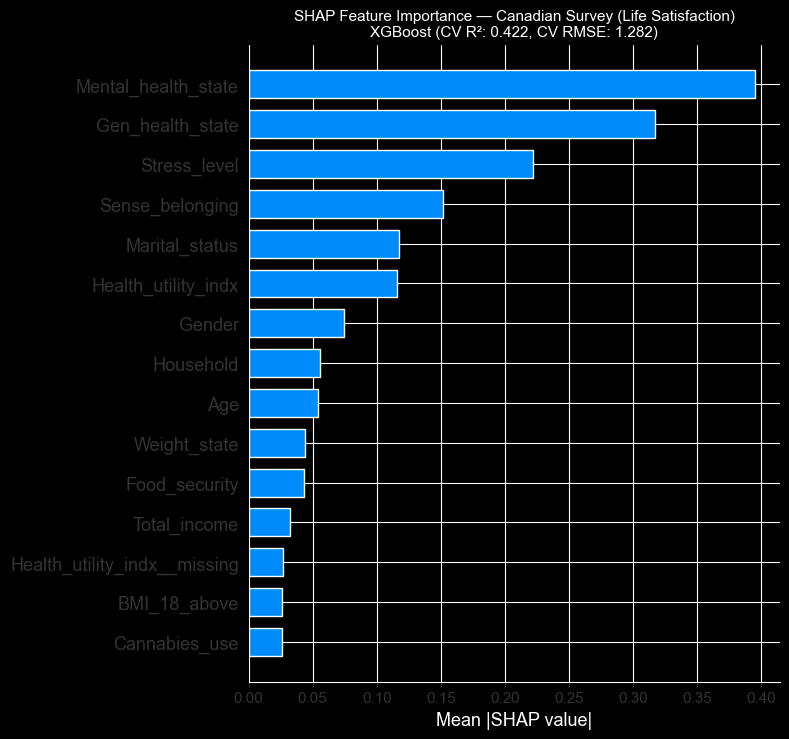

Saved: shap_canadian_survey_bar.png


In [4]:
# Bar plot — global feature importance
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values_can,
    X_sample_can,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Canadian Survey (Life Satisfaction)\n"
    "XGBoost (CV R²: 0.422, CV RMSE: 1.282)",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_canadian_survey_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_canadian_survey_bar.png")

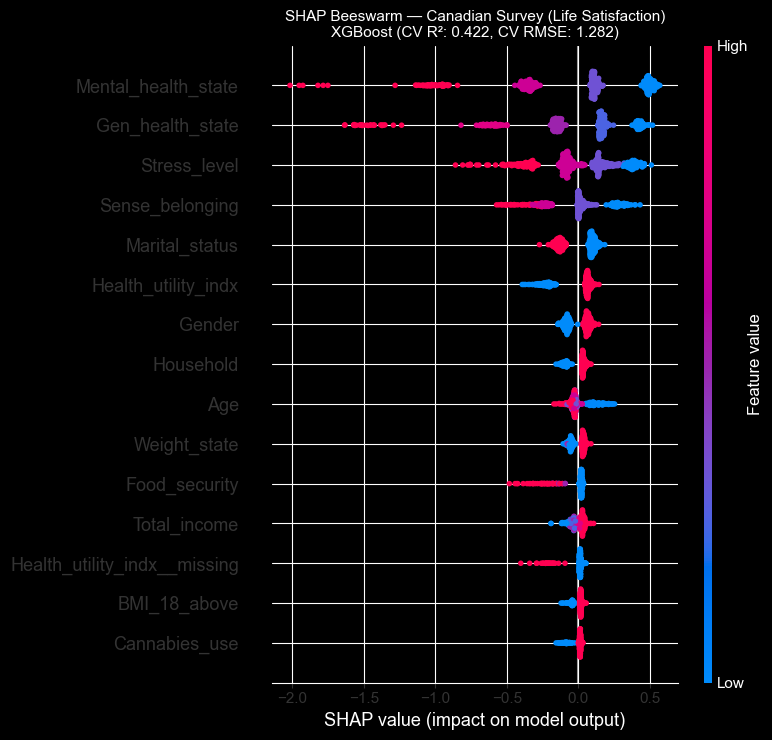

Saved: shap_canadian_survey_beeswarm.png


In [5]:
# Beeswarm plot — direction and magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_can,
    X_sample_can,
    max_display=15,
    show=False
)
plt.title(
    "SHAP Beeswarm — Canadian Survey (Life Satisfaction)\n"
    "XGBoost (CV R²: 0.422, CV RMSE: 1.282)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_canadian_survey_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_canadian_survey_beeswarm.png")

In [6]:
# Sensitivity analysis — model without Mental_health_state and Gen_health_state
# These are self-reported health states from the same survey as Life_satisfaction
# and may act as proxy predictors rather than independent causes

proxy_cols = ["Mental_health_state", "Gen_health_state"]
X_no_proxy = X.drop(columns=[c for c in proxy_cols if c in X.columns])

print(f"Features with proxies:    {X.shape[1]}")
print(f"Features without proxies: {X_no_proxy.shape[1]}")
print(f"Dropped: {proxy_cols}")

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_proxy, y, test_size=0.2, random_state=42
)

xgb_can_np = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_can_np.fit(X_train_np, y_train_np)

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2":   "r2",
    "rmse": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    )
}

scores_np = cross_validate(
    xgb_can_np, X_no_proxy, y,
    cv=cv, scoring=scoring, n_jobs=-1
)

r2_np   = round(scores_np["test_r2"].mean(), 3)
rmse_np = round(-scores_np["test_rmse"].mean(), 3)

print("\nSensitivity Analysis — Without Mental_health_state and Gen_health_state")
print(f"CV R²   (with proxies)    : 0.422")
print(f"CV R²   (without proxies) : {r2_np}")
print(f"CV RMSE (with proxies)    : 1.282")
print(f"CV RMSE (without proxies) : {rmse_np}")
print(f"\nR² drop  : {round(0.422 - r2_np, 3)}")
print(f"RMSE increase : {round(rmse_np - 1.282, 3)}")

Features with proxies:    58
Features without proxies: 56
Dropped: ['Mental_health_state', 'Gen_health_state']

Sensitivity Analysis — Without Mental_health_state and Gen_health_state
CV R²   (with proxies)    : 0.422
CV R²   (without proxies) : 0.314
CV RMSE (with proxies)    : 1.282
CV RMSE (without proxies) : 1.397

R² drop  : 0.108
RMSE increase : 0.115


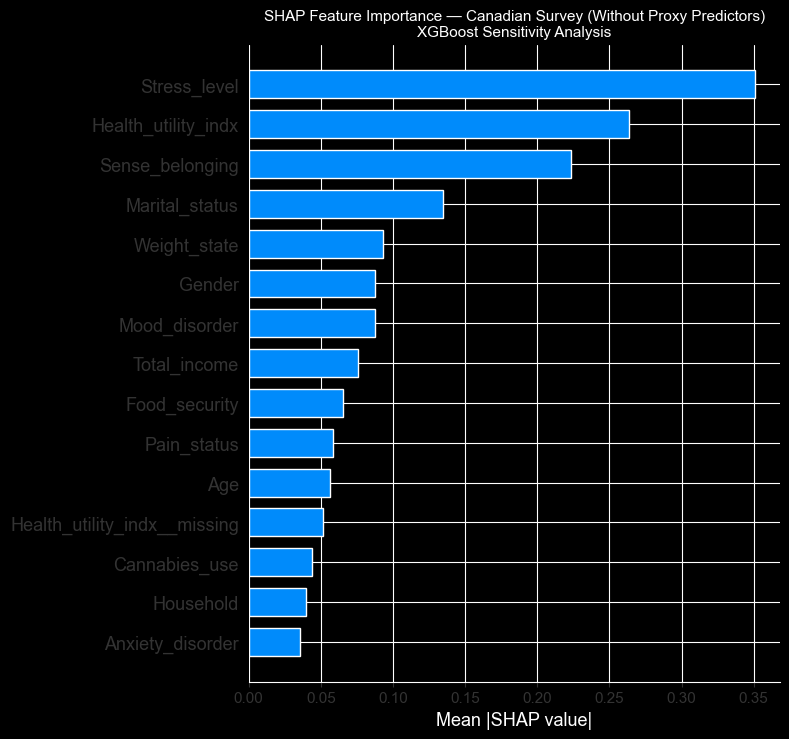

Saved: shap_canadian_survey_bar_noproxy.png


In [7]:
# SHAP for model without proxy predictors
explainer_can_np = shap.TreeExplainer(xgb_can_np)

X_sample_np = X_test_np.sample(n=min(500, len(X_test_np)), random_state=42)
shap_values_np = explainer_can_np.shap_values(X_sample_np)

plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values_np,
    X_sample_np,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Canadian Survey (Without Proxy Predictors)\n"
    "XGBoost Sensitivity Analysis",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_canadian_survey_bar_noproxy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_canadian_survey_bar_noproxy.png")

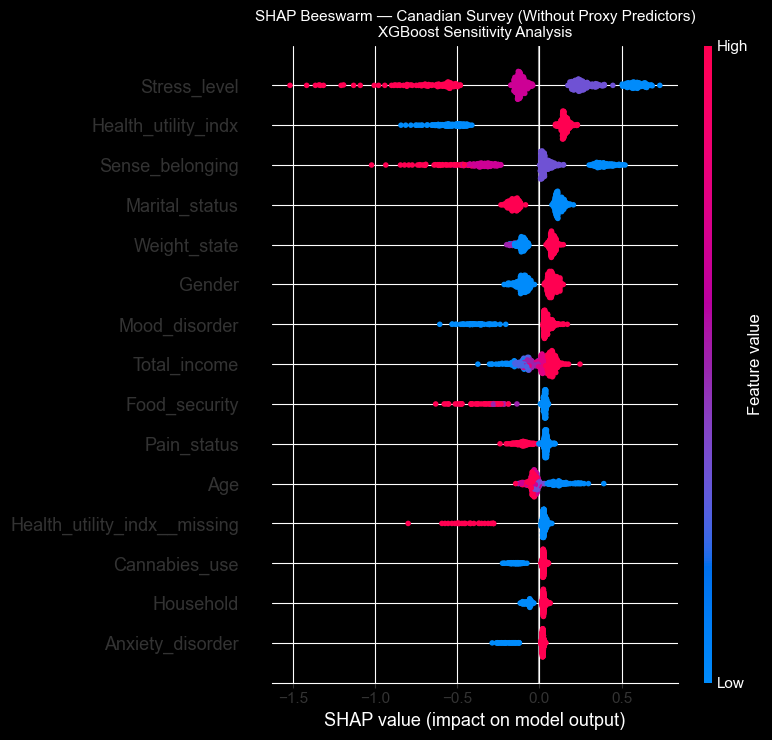

Saved: shap_canadian_survey_beeswarm_noproxy.png


In [8]:
# Beeswarm for model without proxy predictors
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_np,
    X_sample_np,
    max_display=15,
    show=False
)
plt.title(
    "SHAP Beeswarm — Canadian Survey (Without Proxy Predictors)\n"
    "XGBoost Sensitivity Analysis",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_canadian_survey_beeswarm_noproxy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_canadian_survey_beeswarm_noproxy.png")

In [ ]:
# ### SHAP Analysis — Canadian Survey / Life Satisfaction (XGBoost)
#
# **Global feature importance:** Mental_health_state dominates with
# a mean |SHAP| of ~0.40, followed closely by Gen_health_state
# (~0.31). Stress_level (~0.22) and Sense_belonging (~0.15) are the
# next most important predictors, followed by Marital_status (~0.11)
# and Health_utility_indx (~0.10). The remaining features —
# Gender, Household, Age, Weight_state, Food_security,
# Total_income — contribute at much lower magnitudes (~0.03–0.07).
#
# **Direction of effects (beeswarm):** The beeswarm plot reveals
# a strongly asymmetric pattern for the top predictors:
# - Mental_health_state: high values (red, poor mental health)
#   produce large negative SHAP values (-1.5 to -2.0), strongly
#   decreasing predicted life satisfaction. Low values (blue,
#   good mental health) produce small positive SHAP values (~0.3).
#   The effect is highly asymmetric — poor mental health depresses
#   life satisfaction much more strongly than good mental health
#   elevates it.
# - Gen_health_state: same asymmetric pattern — poor general
#   health pushes strongly negative, good health pushes mildly
#   positive.
# - Stress_level: high stress (red) pushes negative, low stress
#   (blue) pushes mildly positive. The distribution is wide,
#   indicating stress varies substantially across respondents.
# - Sense_belonging: strong positive effect for high belonging
#   (blue dots push positive) — a protective factor. Low
#   belonging pushes mildly negative.
# - Marital_status: binary split — one category pushes clearly
#   positive, the other near zero, suggesting married/partnered
#   respondents report higher life satisfaction.
# - Food_security: high food insecurity (red, values 2–3) pushes
#   strongly negative, confirming material deprivation as a
#   meaningful predictor even after controlling for health states.
#
# **Sensitivity analysis — removing Mental_health_state and
# Gen_health_state:**
# Removing the two proxy predictors causes CV R² to drop from
# 0.422 to 0.314 (Δ = 0.108) and CV RMSE to increase from
# 1.282 to 1.397 (Δ = 0.115). This is a substantial drop —
# roughly 25% of explained variance is attributable to these
# two variables.
#
# Importantly, the reduced model remains meaningfully predictive
# (R² = 0.314), confirming genuine signal in the remaining
# features. The sensitivity beeswarm shows Stress_level becomes
# the dominant predictor (~0.35 mean |SHAP|), followed by
# Health_utility_indx (~0.26) and Sense_belonging (~0.22).
# Mood_disorder, Total_income, Food_security, and Pain_status
# emerge more prominently in the reduced model — variables that
# were previously masked by the dominant health state predictors.
#
# This has two important implications. First, Mental_health_state
# and Gen_health_state are genuine predictors rather than pure
# noise — their removal has a real cost. However, their causal
# status is ambiguous: they are self-reported health states from
# the same survey as Life_satisfaction, making construct overlap
# likely. Second, the feature ranking in the reduced model is
# more causally interpretable — Stress_level, Sense_belonging,
# and economic security (Total_income, Food_security) as top
# predictors align with established wellbeing theory and
# represent upstream determinants rather than co-occurring states.
#
# **Connection to theory:** The SHAP profile is consistent with
# the biopsychosocial model of wellbeing. Psychological states
# (mental health, stress), social connectedness (sense of
# belonging, marital status), and material conditions
# (food security, income) each contribute independently to
# life satisfaction. The asymmetric effect of poor health —
# depressing satisfaction more strongly than good health
# elevates it — is consistent with loss aversion in wellbeing
# research and the disproportionate impact of negative
# life events documented in hedonic adaptation literature.
# The prominence of Sense_belonging as a protective factor
# is consistent with social support theory and replicates
# findings from the MH Tech dataset where care availability
# and supervisor support were key predictors of treatment
# seeking, suggesting social connectedness is a cross-context
# resilience factor in wellbeing data.